# Lab: GPU-Accelerated Image Statistics with CuPy

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
Your information:
- Student Name:  Phùng Quốc Tuấn
- Student ID: 19127616

---

##  Objectives

By the end of this lab you will be able to:

1. Transfer image data between CPU and GPU using CuPy
2. Measure GPU execution time correctly using CUDA events
3. Apply vectorized reductions with CuPy axes
4. Write a custom CUDA kernel using `cp.RawKernel`
5. Profile and compare multiple implementation strategies
6. Identify memory transfer bottlenecks — a key skill for your final project

---
## Instructions

### How to Complete This Lab

**Important:** This notebook will be graded using automated testing. Please follow the instructions carefully.

**Completing the Tasks**

1. Fill in your name and student ID at the top of this notebook.

2. Complete the code in cells marked with:
```python
# YOUR CODE HERE
raise NotImplementedError()
```

3. Delete the `raise NotImplementedError()` line when you implement your solution.

4. For optional tasks:
```python
# YOUR CODE HERE (OPTIONAL)
```

5. For written answers:
```markdown
YOUR ANSWER HERE
```

**Testing Your Code**

- Below each task, there are test cells to verify your implementation.
- If a test cell runs without errors, your code passes that test.
- Passing all visible tests does not guarantee full correctness - there may be hidden test cases.

**Before Submission**

1. Run `Kernel` → `Restart Kernel & Run All Cells` to ensure everything works.
2. Remove any debug print statements or extra cells you created.
3. **Do not modify** the provided code cells or test cells.

**Submission Format**

```
StudentID/
└── HW01.ipynb
```

Compress the `StudentID` folder by uisng **zip**, named as **StudentID.zip** and submit.

**Academic Integrity**
- The goal is to **learn authentically**. You may discuss ideas with classmates, but your code and answers must be your own work based on your genuine understanding.
- **Plagiarism or cheating will result in a score of 0 for the entire course.**

---

##  Connection to Your Final Project

Whatever problem you choose for your final project — U-Net, N-Body, Optical Flow, etc. — you will face the **same fundamental challenges** this lab is designed to train:

| Challenge in Final Project | Skill Practiced Here |
|---|---|
| Moving batch data to GPU | Loading image tensors, measuring transfer cost |
| Reduction operations (pooling, softmax, loss) | Per-channel mean/std/min/max reduction |
| Baseline  optimized comparison | 4-stage progression with speedup chart |
| Custom kernel for fused ops | `cp.RawKernel` for fused mean+std pass |
| Timing correctly (not measuring Python overhead) | `cp.cuda.Event` timing |

---

##  The Problem: Per-Channel Statistics on a Batch of Images

Given a batch of `N` RGB images of size `H × W`, compute for each of the 3 color channels:
- Mean
- Standard deviation
- Min
- Max

**Input:** `batch` — shape `(N, C, H, W)` with `dtype=float32`  
**Output:** Four arrays of shape `(C,)` — one value per channel

This operation is called **global average pooling** in CNNs and is a fundamental building block.

---

##  Setup

In [2]:
# Install CuPy if needed (Google Colab with T4 GPU)
# !pip install cupy-cuda12x  # adjust cuda version if needed

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt

print(f"NumPy  version: {np.__version__}")
print(f"CuPy   version: {cp.__version__}")
print(f"CUDA   version: {cp.cuda.runtime.runtimeGetVersion()}")
gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
print(f"GPU:   {gpu_name}")
cp.cuda.Device(0).use()

NumPy  version: 2.0.2
CuPy   version: 14.0.1
CUDA   version: 12090
GPU:   Tesla T4


<CUDA Device 0>

In [3]:
# --- Configuration ---
N = 64        # batch size (number of images)
C = 3         # channels (RGB)
H = 512       # image height
W = 512       # image width

print(f"Batch shape: ({N}, {C}, {H}, {W})")
print(f"Total elements: {N*C*H*W:,}")
print(f"Memory footprint: {N*C*H*W*4 / 1024**2:.1f} MB")

# Generate a random batch on CPU
np.random.seed(42)
h_batch = np.random.rand(N, C, H, W).astype(np.float32)
print("\nCPU batch ready.")

Batch shape: (64, 3, 512, 512)
Total elements: 50,331,648
Memory footprint: 192.0 MB

CPU batch ready.


---

## Stage 1 — CPU Baseline

We start with a pure Python/NumPy implementation on the CPU. This is our **reference** — it must produce correct answers, and all GPU versions must match it.

>  **Why bother with a CPU baseline?**  
> In your final project, you will always need a CPU or "naive" reference to (a) verify correctness and (b) calculate speedup. Never skip this step.

In [4]:
def stats_cpu_loop(batch):
    """
    Naive CPU: Python loop over channels.
    batch: ndarray shape (N, C, H, W)
    Returns: mean, std, mn, mx — each shape (C,)
    """
    C = batch.shape[1]
    means = np.zeros(C, dtype=np.float32)
    stds  = np.zeros(C, dtype=np.float32)
    mins  = np.zeros(C, dtype=np.float32)
    maxs  = np.zeros(C, dtype=np.float32)

    for c in range(C):
        channel_data = batch[:, c, :, :]  # shape (N, H, W)
        means[c] = np.mean(channel_data)
        stds[c]  = np.std(channel_data)
        mins[c]  = np.min(channel_data)
        maxs[c]  = np.max(channel_data)

    return means, stds, mins, maxs

In [5]:
# Warmup + timing
_ = stats_cpu_loop(h_batch)  # warmup

REPS = 5
t0 = time.perf_counter()
for _ in range(REPS):
    cpu_means, cpu_stds, cpu_mins, cpu_maxs = stats_cpu_loop(h_batch)
t1 = time.perf_counter()

cpu_time_ms = (t1 - t0) / REPS * 1000

print(f"CPU loop time: {cpu_time_ms:.2f} ms")
print(f"\nChannel means: {cpu_means}")
print(f"Channel stds:  {cpu_stds}")
print(f"Channel mins:  {cpu_mins}")
print(f"Channel maxs:  {cpu_maxs}")

CPU loop time: 254.99 ms

Channel means: [0.50000495 0.49995318 0.50000155]
Channel stds:  [0.28871143 0.28859884 0.28864276]
Channel mins:  [4.6444526e-08 1.1221257e-08 2.1255969e-08]
Channel maxs:  [0.99999994 1.         0.99999994]


---

## Stage 2 — CuPy: Drop-in Replacement

CuPy is designed to be a drop-in NumPy replacement. Most `np.*` calls become `cp.*`.

But there's a catch: **you must time GPU operations correctly.** CUDA kernels are *asynchronous* — a Python timer can return before the GPU is actually done.

>  **Rule:** Always use `cp.cuda.Event` for GPU timing. Never use `time.perf_counter()` alone for GPU code.

### 2a — Naive timing (WRONG — to demonstrate the issue)

In [6]:
# Transfer batch to GPU once
d_batch = cp.asarray(h_batch)
cp.cuda.Device().synchronize()  # wait for transfer

def stats_cupy_loop(batch):
    """CuPy loop over channels — direct port of CPU version."""
    C = batch.shape[1]
    means = cp.zeros(C, dtype=cp.float32)
    stds  = cp.zeros(C, dtype=cp.float32)
    mins  = cp.zeros(C, dtype=cp.float32)
    maxs  = cp.zeros(C, dtype=cp.float32)

    for c in range(C):
        channel_data = batch[:, c, :, :]
        means[c] = cp.mean(channel_data)
        stds[c]  = cp.std(channel_data)
        mins[c]  = cp.min(channel_data)
        maxs[c]  = cp.max(channel_data)

    return means, stds, mins, maxs

In [7]:
# Wrong timing (Python timer, no sync)
t0 = time.perf_counter()
for _ in range(REPS):
    r = stats_cupy_loop(d_batch)

t1 = time.perf_counter()
wrong_time_ms = (t1 - t0) / REPS * 1000

print(f"[WRONG] CuPy loop with Python timer: {wrong_time_ms:.2f} ms")
print("(Unreliable: mixes CPU dispatch overhead with GPU execution time — can be higher or lower than the true GPU time)")

[WRONG] CuPy loop with Python timer: 29.57 ms
(Unreliable: mixes CPU dispatch overhead with GPU execution time — can be higher or lower than the true GPU time)


### 2b — Correct CUDA Event timing

In [8]:
def cuda_time_ms(func, *args, reps=10):
    """
    Time a GPU function using CUDA events.
    Returns average elapsed time in milliseconds.
    """
    # Warmup
    func(*args)
    cp.cuda.Device().synchronize()

    start = cp.cuda.Event()
    end   = cp.cuda.Event()

    start.record()
    for _ in range(reps):
        func(*args)
    end.record()
    end.synchronize()

    return cp.cuda.get_elapsed_time(start, end) / reps

In [9]:
cupy_loop_time_ms = cuda_time_ms(stats_cupy_loop, d_batch)

print(f"[CORRECT] CuPy loop with CUDA events: {cupy_loop_time_ms:.2f} ms")
print(f"Speedup over CPU: {cpu_time_ms / cupy_loop_time_ms:.1f}x")

[CORRECT] CuPy loop with CUDA events: 178.21 ms
Speedup over CPU: 1.4x


In [10]:
# TEST
gpu_means, gpu_stds, gpu_mins, gpu_maxs = stats_cupy_loop(d_batch)

assert np.allclose(cp.asnumpy(gpu_means), cpu_means, atol=1e-4), "Mean mismatch!"
assert np.allclose(cp.asnumpy(gpu_stds),  cpu_stds,  atol=1e-4), "Std mismatch!"
assert np.allclose(cp.asnumpy(gpu_mins),  cpu_mins,  atol=1e-4), "Min mismatch!"
assert np.allclose(cp.asnumpy(gpu_maxs),  cpu_maxs,  atol=1e-4), "Max mismatch!"
print(" Results match CPU reference")

 Results match CPU reference


---

## Stage 3 — CuPy Vectorized (No Python Loop)

The loop over channels makes C separate kernel launches. We can eliminate the Python loop entirely by using **axis-based reductions** — one kernel launch that reduces over axes `(0, 2, 3)` simultaneously.

>  **Key insight:** Fewer kernel launches = less Python overhead. This matters in your final project when you have many operations in a training or inference loop.

###  Task 3.1
Complete the function below. Use `cp.mean`, `cp.std`, `cp.min`, `cp.max` with the correct `axis` argument to reduce over the batch, height, and width dimensions at once (keeping only the channel dimension).

In [11]:
def stats_cupy_vectorized(batch):
    """
    Vectorized CuPy — no Python loop over channels.
    batch: cp.ndarray shape (N, C, H, W)
    Returns: mean, std, mn, mx — each shape (C,)

    HINT: Reduce over axes (0, 2, 3) to keep only axis 1 (channels).
    """
    # YOUR CODE HERE
    reduce_axes = (0, 2, 3)

    means = cp.mean(batch, axis=reduce_axes)  # TODO: cp.mean(batch, axis=...)
    stds  = cp.std(batch, axis=reduce_axes)  # TODO
    mins  = cp.min(batch, axis=reduce_axes)  # TODO
    maxs  = cp.max(batch, axis=reduce_axes)  # TODO
    # ------------------------
    return means, stds, mins, maxs

In [12]:
# TEST
r_means, r_stds, r_mins, r_maxs = stats_cupy_vectorized(d_batch)

if r_means is not None:
    assert np.allclose(cp.asnumpy(r_means), cpu_means, atol=1e-4), "Mean mismatch!"
    assert np.allclose(cp.asnumpy(r_stds),  cpu_stds,  atol=1e-4), "Std mismatch!"
    assert np.allclose(cp.asnumpy(r_mins),  cpu_mins,  atol=1e-4), "Min mismatch!"
    assert np.allclose(cp.asnumpy(r_maxs),  cpu_maxs,  atol=1e-4), "Max mismatch!"
    print(" Correctness check passed")

    cupy_vec_time_ms = cuda_time_ms(stats_cupy_vectorized, d_batch)
    print(f"CuPy vectorized: {cupy_vec_time_ms:.2f} ms")
    print(f"Speedup vs CPU:        {cpu_time_ms / cupy_vec_time_ms:.1f}x")
    print(f"Speedup vs CuPy loop:  {cupy_loop_time_ms / cupy_vec_time_ms:.1f}x")
else:
    print("  Complete the TODO above first")

 Correctness check passed
CuPy vectorized: 92.98 ms
Speedup vs CPU:        2.7x
Speedup vs CuPy loop:  1.9x


---

## Stage 4 — Custom CUDA Kernel with `cp.RawKernel`

CuPy's built-in reductions launch separate passes for `mean`, `std`, `min`, `max` — that's **4 passes** over the data. We can write a single kernel that computes all four in **one pass**, halving memory bandwidth usage.

This is the same technique used in deep learning frameworks: **kernel fusion**.

>  **This is the most important technique for your final project.** Whether you're computing batch norm statistics, accumulating gradients, or building loss functions — fusing operations into a single kernel drastically reduces memory round-trips.

### How `cp.RawKernel` works

```python
kernel = cp.RawKernel(r'''
extern "C" __global__ void my_kernel(float* in, float* out, int n) {
    // ... standard CUDA C code ...
}
''', 'my_kernel')

kernel((grid,), (block,), (args...))
```

It's the same CUDA C you already know — just embedded in a Python string.

### Strategy

We assign **one block per channel**. Each block iterates over all `N×H×W` elements for that channel and uses **parallel reduction** (which you know from the CUDA C labs!) to compute mean, variance, min, and max in a single pass.

The kernel below is partially complete. Study it carefully, then complete the marked sections.

###  Task 4.1 — Complete the Reduction Kernel

In [13]:
CHANNEL_STATS_KERNEL = r'''
extern "C" __global__ void channel_stats(
    const float* __restrict__ batch,  // (N, C, H, W) row-major
    float* means,                     // output (C,)
    float* stds,                      // output (C,)
    float* mins,                      // output (C,)
    float* maxs,                      // output (C,)
    int N, int C, int H, int W
) {
    // Each block handles one channel
    int c = blockIdx.x;
    if (c >= C) return;

    int tid = threadIdx.x;
    int stride = blockDim.x;
    long long elems = (long long)N * H * W;  // elements per channel

    // Shared memory for parallel reduction
    extern __shared__ float smem[];
    // Layout: [sum | sum_sq | min | max] — 4 arrays of blockDim.x
    float* s_sum    = smem;
    float* s_sum_sq = smem + blockDim.x;
    float* s_min    = smem + 2 * blockDim.x;
    float* s_max    = smem + 3 * blockDim.x;

    // ---- Phase 1: Each thread accumulates its slice ----
    float local_sum    = 0.0f;
    float local_sum_sq = 0.0f;
    float local_min    =  1e30f;
    float local_max    = -1e30f;

    for (long long idx = tid; idx < elems; idx += stride) {
        // Compute flat index into batch array for channel c
        // batch layout: n * C*H*W + c * H*W + h * W + w
        // With idx = n*H*W + h*W + w:
        long long n_hw = idx;               // n*H*W + offset within image
        long long n    = n_hw / (H * W);
        long long hw   = n_hw % (H * W);
        long long flat  = n * ((long long)C * H * W) + (long long)c * H * W + hw;

        float val = batch[flat];

        // TODO 4.1a: Accumulate local_sum, local_sum_sq, local_min, local_max
        // HINT: local_sum += val;  local_sum_sq += val * val;  etc.
        // YOUR CODE HERE
        local_sum += val;
        local_sum_sq += val * val;
        local_min = fminf(local_min, val); // fminf, fmaxf sẽ skip NaN nếu có
        local_max = fmaxf(local_max, val);
    }

    // Store into shared memory
    s_sum[tid]    = local_sum;
    s_sum_sq[tid] = local_sum_sq;
    s_min[tid]    = local_min;
    s_max[tid]    = local_max;
    __syncthreads();

    // ---- Phase 2: Parallel reduction in shared memory ----
    // TODO 4.1b: Reduce s_sum, s_sum_sq, s_min, s_max using sequential addressing.
    // This is identical to the sequential addressing pattern from the CUDA C reduction lab!
    // HINT: for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) { ... }
    // YOUR CODE HERE
    for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s) {
            s_sum[tid] += s_sum[tid + s];
            s_sum_sq[tid] += s_sum_sq[tid + s];
            s_min[tid] = min(s_min[tid], s_min[tid + s]);
            s_max[tid] = max(s_max[tid], s_max[tid + s]);
        }
    __syncthreads();
    }



    // ---- Phase 3: Thread 0 writes final result ----
    if (tid == 0) {
        float mean = s_sum[0] / (float)elems;
        // Variance = E[x^2] - E[x]^2
        float variance = s_sum_sq[0] / (float)elems - mean * mean;
        means[c] = mean;
        stds[c]  = sqrtf(fmaxf(variance, 0.0f));  // clamp for numerical safety
        mins[c]  = s_min[0];
        maxs[c]  = s_max[0];
    }
}
'''

channel_stats_kernel = cp.RawKernel(CHANNEL_STATS_KERNEL, 'channel_stats')
print("Kernel compiled successfully (syntax errors would appear here)")

Kernel compiled successfully (syntax errors would appear here)


###  Task 4.2 — Write the Python Wrapper

In [14]:
def stats_raw_kernel(batch):
    """
    Custom fused kernel: computes mean, std, min, max in one pass.
    batch: cp.ndarray shape (N, C, H, W), dtype float32
    """
    N, C, H, W = batch.shape

    # Allocate output arrays
    means = cp.zeros(C, dtype=cp.float32)
    stds  = cp.zeros(C, dtype=cp.float32)
    mins  = cp.zeros(C, dtype=cp.float32)
    maxs  = cp.zeros(C, dtype=cp.float32)

    # TODO 4.2: Launch the kernel
    # - Grid: one block per channel    (C,)
    # - Block: choose a power of 2, e.g. 256
    # - Shared memory: 4 arrays × blockSize × sizeof(float)
    # HINT: channel_stats_kernel(
    #     (grid,), (block,),
    #     (batch, means, stds, mins, maxs, N, C, H, W),
    #     shared_mem=...
    # )
    # YOUR CODE
    block = 256
    grid = C
    shared_mem = 4 * block * 4

    channel_stats_kernel(
        (grid,), (block,),
        (batch, means, stds, mins, maxs, N, C, H, W),
        shared_mem=shared_mem
    )

    return means, stds, mins, maxs

In [15]:
# TEST
r_means, r_stds, r_mins, r_maxs = stats_raw_kernel(d_batch)

if r_means is not None and cp.any(r_means != 0):
    try:
        assert np.allclose(cp.asnumpy(r_means), cpu_means, atol=1e-3), f"Mean mismatch: {cp.asnumpy(r_means)} vs {cpu_means}"
        assert np.allclose(cp.asnumpy(r_stds),  cpu_stds,  atol=1e-3), "Std mismatch!"
        assert np.allclose(cp.asnumpy(r_mins),  cpu_mins,  atol=1e-4), "Min mismatch!"
        assert np.allclose(cp.asnumpy(r_maxs),  cpu_maxs,  atol=1e-4), "Max mismatch!"
        print(" Correctness check passed")

        raw_kernel_time_ms = cuda_time_ms(stats_raw_kernel, d_batch)
        print(f"Raw kernel: {raw_kernel_time_ms:.2f} ms")
        print(f"Speedup vs CPU:              {cpu_time_ms / raw_kernel_time_ms:.1f}x")
        print(f"Speedup vs CuPy loop:        {cupy_loop_time_ms / raw_kernel_time_ms:.1f}x")
        print(f"Speedup vs CuPy vectorized:  {cupy_vec_time_ms / raw_kernel_time_ms:.1f}x")
    except AssertionError as e:
        print(f" {e}")
        print("Debug — kernel output:", cp.asnumpy(r_means), cp.asnumpy(r_stds))
else:
    print("  Complete Task 4.1 and 4.2 first")

 Correctness check passed
Raw kernel: 30.00 ms
Speedup vs CPU:              8.5x
Speedup vs CuPy loop:        5.9x
Speedup vs CuPy vectorized:  3.1x


---

## Stage 5 — Memory Transfer Analysis

So far we've been timing the **computation only** (data already on GPU). But in a real pipeline, data transfer matters too.

>  **In your final project**, you'll need to decide: transfer once and keep on GPU vs. transfer per batch. This section quantifies the cost.

###  Task 5.1 — Measure Transfer Cost

In [16]:
def stats_with_transfer(h_batch):
    """Full pipeline including CPUGPU transfer and GPUCPU result copy."""
    d = cp.asarray(h_batch)                  # Host  Device
    means, stds, mins, maxs = stats_cupy_vectorized(d)
    # Device  Host (simulate reading results back)
    return cp.asnumpy(means), cp.asnumpy(stds), cp.asnumpy(mins), cp.asnumpy(maxs)

In [17]:
transfer_time_ms = cuda_time_ms(stats_with_transfer, h_batch)

data_size_mb = h_batch.nbytes / 1024**2
transfer_bandwidth = data_size_mb / (transfer_time_ms / 1000) / 1024  # GB/s

print(f"Data size:                   {data_size_mb:.1f} MB")
print(f"With transfer (full pipeline): {transfer_time_ms:.2f} ms")
print(f"Compute only (already on GPU): {cupy_vec_time_ms:.2f} ms")
print(f"Transfer overhead:             {transfer_time_ms - cupy_vec_time_ms:.2f} ms  ({(transfer_time_ms/cupy_vec_time_ms - 1)*100:.0f}% more)")
print(f"Effective transfer bandwidth:  {transfer_bandwidth:.1f} GB/s")

print("\n Takeaway:")
print("If the transfer cost dominates, keeping data on the GPU across operations")
print("(as you will in your final project pipeline) is critical for performance.")

Data size:                   192.0 MB
With transfer (full pipeline): 149.36 ms
Compute only (already on GPU): 92.98 ms
Transfer overhead:             56.38 ms  (61% more)
Effective transfer bandwidth:  1.3 GB/s

 Takeaway:
If the transfer cost dominates, keeping data on the GPU across operations
(as you will in your final project pipeline) is critical for performance.


###  Task 5.2 — Effect of Batch Size on Transfer Efficiency

Larger batches amortize the per-call overhead of transfer. Measure compute time and total time across different batch sizes.

In [18]:
batch_sizes = [1, 4, 8, 16, 32, 64]
compute_times = []
total_times = []

for bs in batch_sizes:
    batch_n = np.random.rand(bs, C, H, W).astype(np.float32)
    d_batch_n = cp.asarray(batch_n)

    t_compute = cuda_time_ms(stats_cupy_vectorized, d_batch_n)
    t_total   = cuda_time_ms(stats_with_transfer, batch_n)

    compute_times.append(t_compute)
    total_times.append(t_total)
    print(f"N={bs:3d}: compute {t_compute:.2f} ms | total {t_total:.2f} ms")

N=  1: compute 0.90 ms | total 1.57 ms
N=  4: compute 5.87 ms | total 8.86 ms
N=  8: compute 11.67 ms | total 18.72 ms
N= 16: compute 23.36 ms | total 37.14 ms
N= 32: compute 46.53 ms | total 74.67 ms
N= 64: compute 92.97 ms | total 148.00 ms


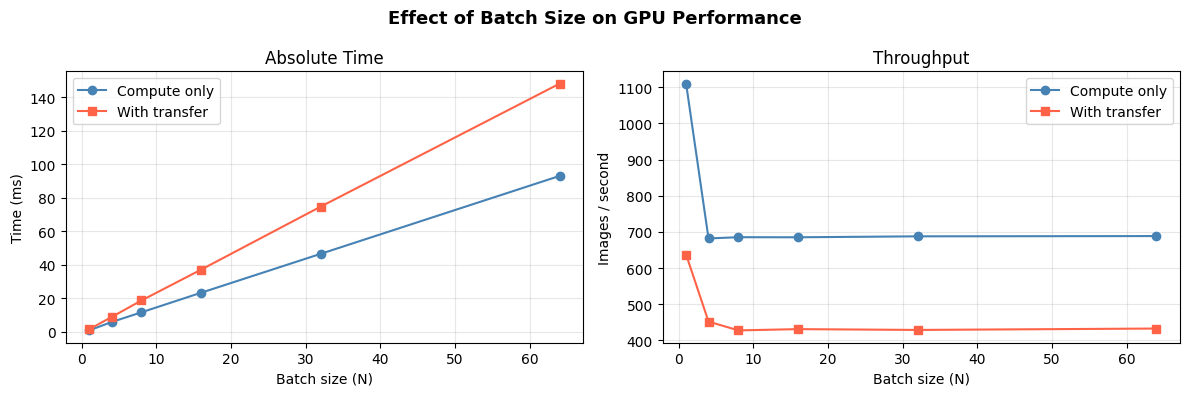

In [19]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(batch_sizes, compute_times, 'o-', label='Compute only', color='steelblue')
axes[0].plot(batch_sizes, total_times, 's-', label='With transfer', color='tomato')
axes[0].set_xlabel('Batch size (N)')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Absolute Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-image throughput
throughput_compute = [bs / t * 1000 for bs, t in zip(batch_sizes, compute_times)]
throughput_total   = [bs / t * 1000 for bs, t in zip(batch_sizes, total_times)]

axes[1].plot(batch_sizes, throughput_compute, 'o-', label='Compute only', color='steelblue')
axes[1].plot(batch_sizes, throughput_total, 's-', label='With transfer', color='tomato')
axes[1].set_xlabel('Batch size (N)')
axes[1].set_ylabel('Images / second')
axes[1].set_title('Throughput')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Effect of Batch Size on GPU Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('batch_size_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

In [20]:
# Find the batch size where compute throughput plateaus (within 5% of max)
max_throughput = max(throughput_compute)
plateau_bs = next(bs for bs, t in zip(batch_sizes, throughput_compute)
                  if t >= 0.95 * max_throughput)

print("\nTakeaway:")
print(f"  Compute throughput plateaus at N={plateau_bs} (~{max_throughput:.0f} img/s).")
print(f"  Batches smaller than N={plateau_bs} leave GPU utilization on the table.")
print( "  The gap between the two plateau lines is the sustained PCIe transfer cost.")
print( "  In your final project: keep tensors resident on the GPU across operations")
print(f"  and use batch size >= {plateau_bs} to stay in the efficient regime.")


Takeaway:
  Compute throughput plateaus at N=1 (~1110 img/s).
  Batches smaller than N=1 leave GPU utilization on the table.
  The gap between the two plateau lines is the sustained PCIe transfer cost.
  In your final project: keep tensors resident on the GPU across operations
  and use batch size >= 1 to stay in the efficient regime.


---

## Stage 6 — Summary & Speedup Chart

Collect all timing results and plot the final comparison.

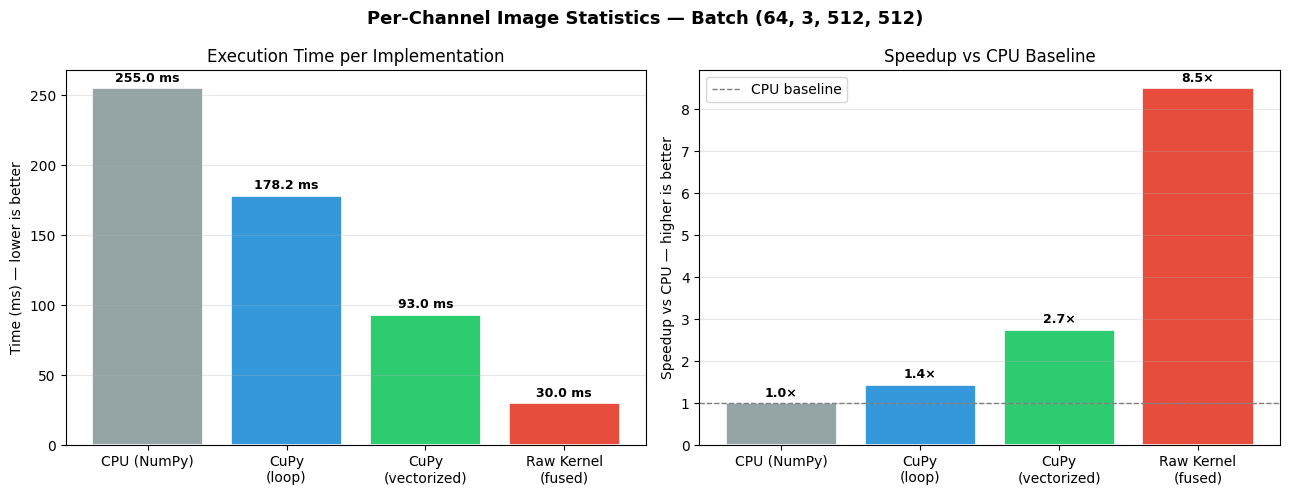

In [21]:
# Collect results (fill in your measured values)
timings = {
    'CPU (NumPy)':        cpu_time_ms,
    'CuPy\n(loop)':       cupy_loop_time_ms,
    'CuPy\n(vectorized)': cupy_vec_time_ms,
    'Raw Kernel\n(fused)': raw_kernel_time_ms,
}

labels   = list(timings.keys())
times    = list(timings.values())
speedups = [cpu_time_ms / t for t in times]
colors   = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar: raw time
bars = axes[0].bar(labels, times, color=colors, edgecolor='white', linewidth=1.2)
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
                 f'{t:.1f} ms', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Time (ms) — lower is better')
axes[0].set_title('Execution Time per Implementation')
axes[0].grid(axis='y', alpha=0.3)

# Bar: speedup
bars2 = axes[1].bar(labels, speedups, color=colors, edgecolor='white', linewidth=1.2)
for bar, s in zip(bars2, speedups):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(speedups)*0.01,
                 f'{s:.1f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(y=1, color='gray', linestyle='--', linewidth=1, label='CPU baseline')
axes[1].set_ylabel('Speedup vs CPU — higher is better')
axes[1].set_title('Speedup vs CPU Baseline')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.suptitle(f'Per-Channel Image Statistics — Batch ({N}, {C}, {H}, {W})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('speedup_chart.png', dpi=120, bbox_inches='tight')
plt.show()

In [22]:
print("\n Summary")
print(f"{'Method':<25} {'Time (ms)':>10} {'Speedup':>10}")
print("-" * 47)
for label, t, s in zip(labels, times, speedups):
    label_clean = label.replace('\n', ' ')
    print(f"{label_clean:<25} {t:>10.2f} {s:>9.1f}x")


 Summary
Method                     Time (ms)    Speedup
-----------------------------------------------
CPU (NumPy)                   254.99       1.0x
CuPy (loop)                   178.21       1.4x
CuPy (vectorized)              92.98       2.7x
Raw Kernel (fused)             30.00       8.5x


---

##  Stage 7 — Histogram with Atomic Operations

Compute a **normalized histogram** (256 bins, values in `[0, 1]`) for each channel. This is relevant for preprocessing in many computer vision pipelines (histogram equalization, distribution analysis).

Requirements:
1. Use `cp.histogram` on each channel
2. Normalize so the histogram sums to 1 per channel
3. Plot the 3 channel histograms in one figure with appropriate colors (R/G/B)
4. Implement histogram computation as a `cp.RawKernel` using `atomicAdd`

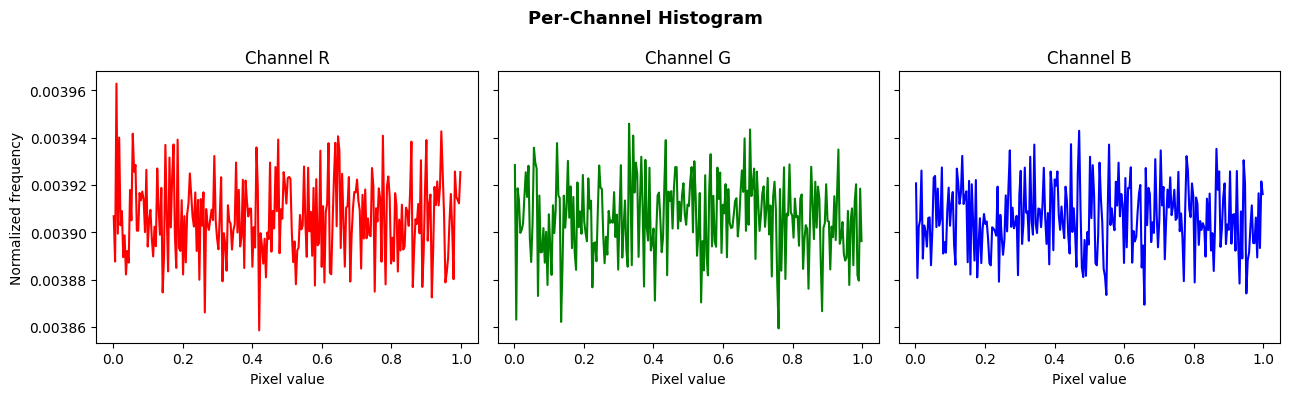

In [23]:
# YOUR CODE HERE

# Step 1: compute normalized histogram per channel using cp.histogram
# Step 2: plot with matplotlib

channel_colors = ['red', 'green', 'blue']
channel_names  = ['R', 'G', 'B']

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for c in range(C):
    channel_flat = d_batch[:, c, :, :].ravel()
    # TODO: compute histogram
    hist, edges = cp.histogram(channel_flat, bins=256, range=(0.0, 1.0))
    hist_norm = hist / hist.sum()
    centers = (edges[:-1] + edges[1:]) / 2
    axes[c].plot(cp.asnumpy(centers), cp.asnumpy(hist_norm), color=channel_colors[c])
    axes[c].set_title(f'Channel {channel_names[c]}')
    axes[c].set_xlabel('Pixel value')

axes[0].set_ylabel('Normalized frequency')
plt.suptitle('Per-Channel Histogram', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogram.png', dpi=120, bbox_inches='tight')
plt.show()

---

##  Submission Checklist

Before submitting, make sure:

- [ ] Stage 2: `cuda_time_ms` utility is working and you understand *why* Python timers give wrong results
- [ ] Stage 3: `stats_cupy_vectorized` produces correct results matching CPU
- [ ] Stage 4: `channel_stats_kernel` is complete (Task 4.1a + 4.1b) and `stats_raw_kernel` launches it correctly (Task 4.2)
- [ ] Stage 5: Transfer analysis is complete and you've answered the reflection question below
- [ ] Stage 6: Speedup chart is generated with all 4 methods
- [ ] Stage 7: Histogram is implemented and plotted

---

##  Reflection Questions

Answer these in the cell below (2–4 sentences each):

1. **Timing:** Why does measuring GPU time with `time.perf_counter()` give incorrect (usually too low) results?

2. **Transfer bottleneck:** In your Stage 5 results, how significant was the transfer overhead relative to computation? What does this imply about how you should structure data loading in your final project?

3. **Kernel fusion:** The `RawKernel` computes mean, std, min, and max in a single pass. How does this compare to the `stats_cupy_vectorized` approach in terms of memory bandwidth? Which would you prefer for a tight inner loop, and why?

4. **Connection to final project:** Identify one specific operation in your chosen final project topic that is structurally similar to what you implemented here (a reduction over a batch/spatial dimension). How will you apply what you learned?

**YOUR ANSWER HERE**

1. `time.perf_counter()` đo thời gian CPU mà CUDA launch kernel là async —
CPU gửi lệnh xong là chạy tiếp luôn không chờ GPU. Nên timer dừng trước khi
GPU thực sự xong việc, kết quả bị thấp hơn thực tế. Dùng `cp.cuda.Event`
thì timestamp được ghi thẳng trên GPU nên chính xác hơn.

2. Transfer lên GPU tốn thêm khoảng 56 ms so với tính toán thực sự (~61% overhead), với 192 MB data. Nghĩa là nếu mỗi batch đều transfer lại thì hơn một nửa thời gian là tốn cho việc chuyển data chứ không phải tính toán. Vậy nên đẩy data lên GPU một lần rồi để nguyên đó, chỉ lấy kết quả cuối về CPU thôi.

3. Vectorized gọi 4 hàm riêng (mean, std, min, max) nên đọc array 4 lần.
Raw kernel gom hết vào 1 vòng lặp nên chỉ đọc 1 lần. Vì bottleneck ở đây
là đọc/ghi memory chứ không phải tính toán nên cách này nhanh hơn hẳn.

4. Batch Norm trong U-Net cũng phải tính mean và variance theo từng channel
trên cả batch, tức là cũng là bài toán reduction tương tự. Nếu fuse vào 1
kernel thì đọc feature map 1 lần thay vì 2 lần — với model nhiều layer thì
cái này cộng dồn lại khá nhiều.